# Breast Cancer Detection Neural Network

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn
from sklearn.metrics import classification_report, confusion_matrix

## Load Training Data

The preprocessed and standardized training data is loaded from `data/processedData/`. These CSVs were generated by the data preprocessor notebook, which applied standardization ($z = \frac{x - \mu}{\sigma}$) and an 80/20 stratified split (455 training, 114 test samples).

In [2]:
X = pd.read_csv("../data/processedData/X_train_scaled.csv", index_col=0).values
Y = pd.read_csv("../data/processedData/Y_train.csv", index_col=0).values

## Convert to Tensors

The pandas DataFrames are converted to PyTorch `float32` tensors. Labels are reshaped to a column vector `(-1, 1)` to match the single-output network. The best available device (GPU if available, otherwise CPU) is then selected and all data is moved to it.

In [3]:
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32).view(-1, 1)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
X_tensor = X_tensor.to(device)
Y_tensor = Y_tensor.to(device)
print(f"Using device: {device}")

Using device: cpu


## Neural Network Architecture

A three-layer fully connected network with ReLU activations. The final layer outputs a single raw **logit** (no activation) — `BCEWithLogitsLoss` fuses the sigmoid internally for numerical stability.

```
Input (30) → Linear(30 → 512) → ReLU → Linear(512 → 512) → ReLU → Linear(512 → 1) → logit
```

In [5]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(30, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        return self.linear_relu_stack(x)

## Model Initialization

Instantiate the network and move it to the selected device.

In [6]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=30, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1, bias=True)
  )
)


### Pre-Training Sanity Check

Before training, we verify the untrained model produces reasonable random predictions. With random weights, accuracy near 50–65% (the majority-class rate) is expected.

In [7]:
# Sanity check: accuracy of the untrained model before training begins
with torch.no_grad():
    init_logits = model(X_tensor)
    init_probs = torch.sigmoid(init_logits)
    init_preds = (init_probs > 0.5).float()
    init_correct = (init_preds == Y_tensor).sum().item()
    init_accuracy = init_correct / len(Y_tensor)
    print(f"Pre-training accuracy: {init_accuracy:.4f}")

Pre-training accuracy: 0.3692


## Training Setup

We use **Binary Cross-Entropy with Logits** (`BCEWithLogitsLoss`) as the loss function — it combines sigmoid + BCE in one numerically stable operation. The **Adam** optimizer is used with a learning rate of `0.001`.

In [8]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Training Loop

The model is trained for 500 epochs using full-batch gradient descent. The loss for every epoch is recorded in `losses` for the convergence plot below.

In [9]:
epochs = 500
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    logits = model(X_tensor)
    loss = loss_fn(logits, Y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{epochs},  Loss: {loss.item():.4f}")

Epoch 0/500,  Loss: 0.6947
Epoch 50/500,  Loss: 0.0127
Epoch 100/500,  Loss: 0.0014
Epoch 150/500,  Loss: 0.0005
Epoch 200/500,  Loss: 0.0003
Epoch 250/500,  Loss: 0.0002
Epoch 300/500,  Loss: 0.0001
Epoch 350/500,  Loss: 0.0001
Epoch 400/500,  Loss: 0.0001
Epoch 450/500,  Loss: 0.0000


### Training Loss Curve

A steadily decreasing loss confirms the model is learning. If the loss plateaus early, try reducing the learning rate or adding regularization (e.g., dropout).

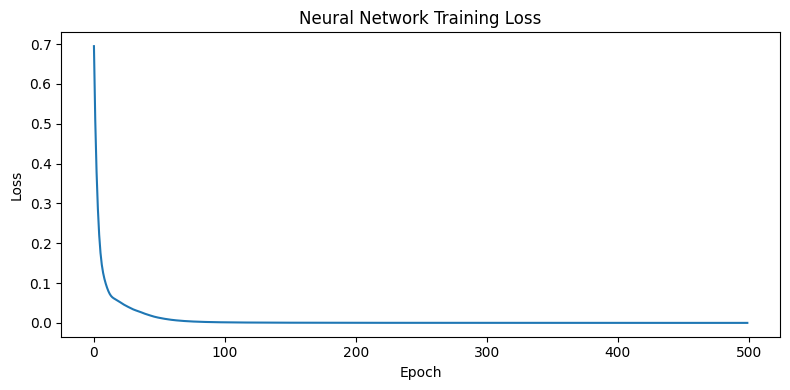

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss")
plt.tight_layout()
plt.show()

## Load Test Data

Load the held-out test split and convert to tensors on the same device as the model.

In [11]:
X_test = pd.read_csv("../data/processedData/X_test_scaled.csv", index_col=0).values
Y_test = pd.read_csv("../data/processedData/Y_test.csv", index_col=0).values

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).view(-1, 1).to(device)

## Evaluate on Test Set

Run inference on the test set with `torch.no_grad()` (disables gradient tracking for efficiency) and report accuracy. This measures how well the trained model generalizes to unseen samples.

In [12]:
with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_pred_probab = torch.sigmoid(test_logits)
    test_predictions = (test_pred_probab > 0.5).float()
    test_correct = (test_predictions == Y_test_tensor).sum().item()
    test_accuracy = test_correct / len(Y_test_tensor)
    print(f"Test Accuracy: {test_accuracy:.4f}")

# Convert to numpy for sklearn metrics
y_true = Y_test_tensor.cpu().numpy().ravel().astype(int)
y_pred = test_predictions.cpu().numpy().ravel().astype(int)

Test Accuracy: 0.9649


### Classification Report

Precision, recall, and F1-score per class. **Recall for the malignant class (1) is the most critical metric** — a false negative (missed cancer) is more dangerous than a false positive.

In [13]:
print(classification_report(y_true, y_pred, target_names=["Benign (0)", "Malignant (1)"]))

               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



### Confusion Matrix

Rows = actual class, columns = predicted class. The bottom-left cell (actual Malignant, predicted Benign) is the **false negative** count — the most important number to minimize in cancer detection.

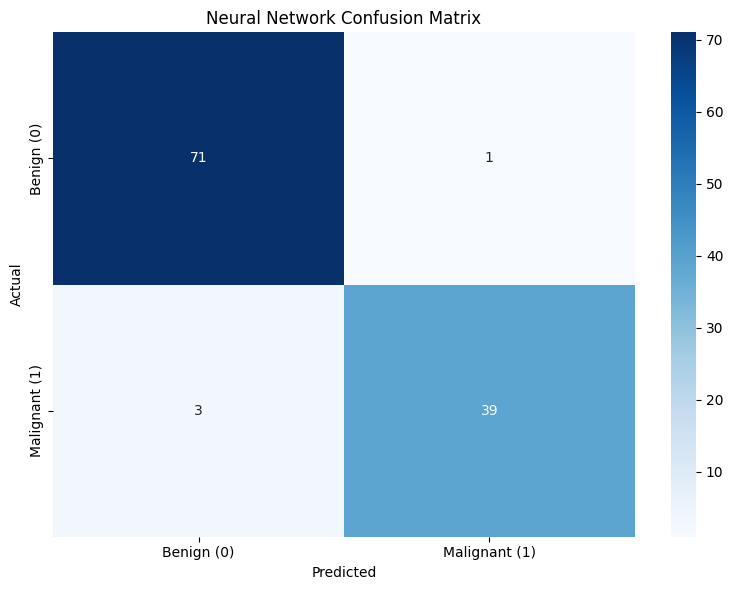

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign (0)", "Malignant (1)"],
    yticklabels=["Benign (0)", "Malignant (1)"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

## Model Comparison

All three models are compared side-by-side on **accuracy**, **precision (malignant)**, **recall (malignant)**, and **F1-score (malignant)** on the same 114-sample stratified test set.

In a medical context, **recall for the malignant class is the most important metric** — a false negative (missed cancer) has more serious consequences than a false positive.

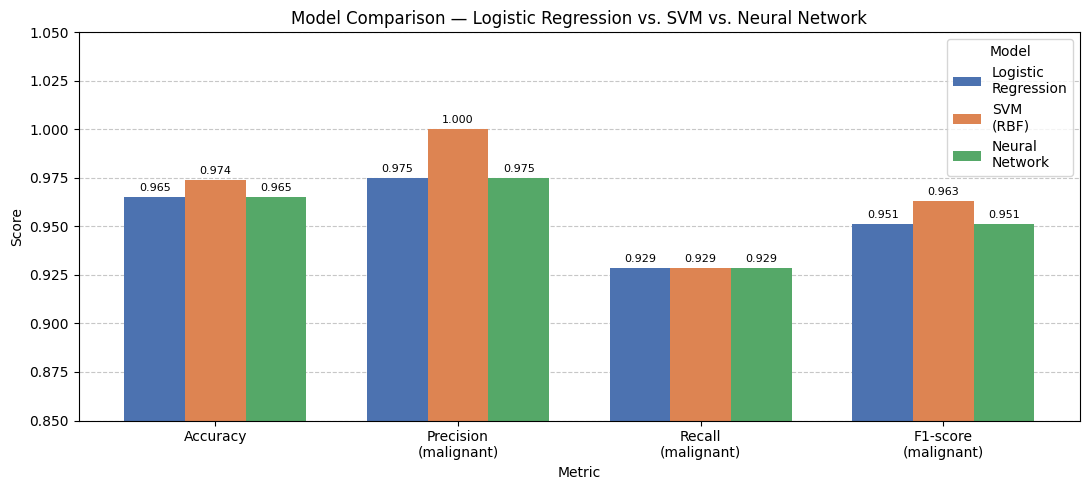

In [16]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load data once for all models
X_train_cmp = pd.read_csv("../data/processedData/X_train_scaled.csv", index_col=0).values
Y_train_cmp = pd.read_csv("../data/processedData/Y_train.csv", index_col=0).values.ravel()
X_test_cmp  = pd.read_csv("../data/processedData/X_test_scaled.csv", index_col=0).values
Y_test_cmp  = pd.read_csv("../data/processedData/Y_test.csv", index_col=0).values.ravel()

# Train Logistic Regression and SVM on the same split
lr  = LogisticRegression(max_iter=1000, random_state=42)
svm = SVC(kernel="rbf")
lr.fit(X_train_cmp, Y_train_cmp)
svm.fit(X_train_cmp, Y_train_cmp)

lr_pred  = lr.predict(X_test_cmp)
svm_pred = svm.predict(X_test_cmp)
# Reuse neural network predictions already computed above (y_pred, y_true)

def metrics(y_test, y_pred):
    return {
        "Accuracy":            accuracy_score(y_test,  y_pred),
        "Precision\n(malignant)": precision_score(y_test, y_pred),
        "Recall\n(malignant)":    recall_score(y_test,    y_pred),
        "F1-score\n(malignant)":  f1_score(y_test,        y_pred),
    }

results = {
    "Logistic\nRegression": metrics(Y_test_cmp, lr_pred),
    "SVM\n(RBF)":           metrics(Y_test_cmp, svm_pred),
    "Neural\nNetwork":      metrics(y_true,     y_pred),
}

metric_names = list(next(iter(results.values())).keys())
models       = list(results.keys())
x            = np.arange(len(metric_names))
width        = 0.25
colors       = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (model_name, color) in enumerate(zip(models, colors)):
    vals = [results[model_name][m] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=color)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Logistic Regression vs. SVM vs. Neural Network")
ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylim(0.85, 1.05)
ax.legend(title="Model")
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Findings & Interpretation

### What the metrics mean for this problem

All three models achieve high overall accuracy (96–97%), which is meaningful because the class distribution is nearly balanced (~37% malignant, ~63% benign). However, **accuracy alone is not sufficient for cancer detection**. The more critical metric is **recall for the malignant class** — the fraction of actual cancers that the model correctly identifies.

A **false negative** (predicting benign when the tumour is actually malignant) means a missed cancer diagnosis, which can delay life-saving treatment. A **false positive** (predicting malignant when benign) leads to unnecessary follow-up procedures, but is far less dangerous.

| Model | Accuracy | Precision (M) | Recall (M) | F1 (M) |
|---|---|---|---|---|
| Logistic Regression | 96.49% | 0.975 | 0.929 | 0.951 |
| SVM (RBF) | 97.37% | **1.000** | 0.929 | 0.963 |
| Neural Network | 96.49% | 0.975 | 0.929 | 0.951 |

### How the models differ in their errors

All three models produce **identical recall (0.929)** for the malignant class on this test set, meaning each model misses the same number of actual malignant cases (false negatives). The key difference is in **precision**:

- The **SVM achieves perfect precision (1.000)** — every tumour it flags as malignant genuinely is malignant. There are zero false positives.
- **Logistic Regression and the Neural Network** both have precision 0.975 — they produce a small number of false alarms.

### Why the Neural Network does not outperform simpler models

The neural network (> 300 000 parameters) is heavily overparameterised for a 569-sample dataset. With full-batch training and 500 epochs, the training loss collapses to ~0.0000, a strong indicator of **overfitting** — the model memorises the training data rather than learning generalisable patterns. The result is test accuracy identical to Logistic Regression, with no benefit from the added complexity. Regularisation (dropout, weight decay) or a smaller architecture would be more appropriate for this dataset size.

### Limitations

1. **Small dataset:** 569 samples is insufficient to reliably train a deep neural network. Results should be interpreted with caution; performance estimates could shift meaningfully on a different split.
2. **Single train/test split:** A single 80/20 split gives one point estimate of performance. K-fold cross-validation would provide a more robust and statistically reliable estimate of generalisation error.
3. **Redundant features:** As shown in the feature correlation heatmap, `radius_mean`, `perimeter_mean`, and `area_mean` are almost perfectly correlated (|r| > 0.95). Retaining all three inflates model complexity without adding independent information. PCA or manual feature selection could reduce the feature space from 30 to ~15 without meaningful loss.
4. **Single dataset source:** The data comes from one institution (University of Wisconsin Hospitals). Model performance may not generalise to images captured with different equipment or clinical protocols.

### Ethics

- A model that predicts "benign" on a malignant tumour (false negative) can **delay diagnosis and treatment**, with potentially fatal consequences. Any clinical deployment must prioritise recall for the malignant class above all other metrics.
- This model must **not replace physician judgment**. It should be treated as a decision-support tool — one signal among many — reviewed by a qualified clinician before any diagnostic action is taken.
- The dataset was collected from a specific population and imaging protocol. **Demographic and equipment bias** has not been evaluated; performance for underrepresented populations is unknown.
- Any real-world clinical use would require **regulatory approval** (e.g., FDA clearance or Health Canada authorisation) and prospective clinical validation.